# Project: Object Detection with YOLO

**Overview:** Perform object detection using the YOLO model.

**Task:** Object Detection
**Dataset:** Image dataset


## Dataset Setup & Data Exploration

In this section, we load the dataset and inspect how many images are available.

In [ ]:
#Install YOLO and import required libraries
!pip install ultralytics
from ultralytics import YOLO
import os
import cv2
import matplotlib.pyplot as plt
import random

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 33.5 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


### Upload dataset to colab

We will upload the dataset as zip folder exported in YOLO format, then unzip it.
Expected structure:

* train/images, train/labels
* valid/images, valid/labels
* test/images, test/labels
* data.yaml

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving dataset.zip to dataset.zip


In [ ]:
!unzip dataset.zip

Archive:  dataset.zip
  inflating: README.dataset.txt      
  inflating: README.roboflow.txt     
  inflating: data.yaml               
   creating: test/
   creating: test/images/
 extracting: test/images/15_webp.rf.3c850bceff459870d428ba2151f26e8e.jpg  
 extracting: test/images/25_jpg.rf.8a04e1db0ee287dfa61c85364e8455c4.jpg  
 extracting: test/images/33_jpg.rf.bfbdc45ed428b1adf2ac737b51691ee2.jpg  
 extracting: test/images/35_jpg.rf.3e56c7f35d883881dd161713aca08365.jpg  
 extracting: test/images/38_jpg.rf.8f408a22ba0ac09171ec936e36c3ec42.jpg  
 extracting: test/images/3_webp.rf.7496df9d65e92a20fb24fd42fa320393.jpg  
 extracting: test/images/47_jpg.rf.ba96893eea50124c048f7b769c2caa82.jpg  
 extracting: test/images/49_png.rf.c9b609a44e515eb1fd1f56884129ad0a.jpg  
 extracting: test/images/4_jpg.rf.e3d1e9e874690125ef42ba9be24029b8.jpg  
 extracting: test/images/62_webp.rf.baceb4510c04ad412670d1f3aeb651a2.jpg  
   creating: test/labels/
  inflating: test/labels/15_webp.rf.3c850bceff459870

In [ ]:
train_imgs = len(os.listdir("train/images"))
val_imgs = len(os.listdir("valid/images"))
test_imgs = len(os.listdir("test/images"))

print("Train images:", train_imgs)
print("Validation images:", val_imgs)
print("Test images:", test_imgs)
print("Total images:", train_imgs + val_imgs + test_imgs)

Train images: 117
Validation images: 30
Test images: 10
Total images: 157


## Visualization Checks

Before training, we visualize random training images with their bounding boxes. This confirms labels are aligned with objects.

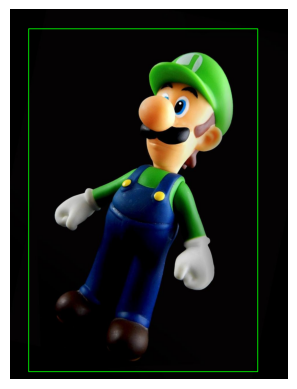

In [ ]:
def show_image_with_boxes(img_path, label_path):
    img = cv2.imread(img_path)
    h, w, _ = img.shape

    # read labels if available and draw each box
    with open(label_path) as f:
      for line in f:
        cls, xc, yc, bw, bh = map(float, line.split())
        x1 = int((xc - bw/2) * w)
        y1 = int((yc - bh/2) * h)
        x2 = int((xc + bw/2) * w)
        y2 = int((yc + bh/2) * h)
        cv2.rectangle(img, (x1,y1), (x2,y2), (0,255,0), 2)

    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()

# Random
img_name = random.choice(os.listdir("train/images"))
show_image_with_boxes(
      f"train/images/{img_name}",
      f"train/labels/{img_name.replace('.jpg', '.txt')}"
  )


## Model Building with YOLO

We train a YOLO detection model using "yolov8n.pt". Augmentation is enabled during training (augment = True) to improve generalization.

In [ ]:
# Load a pretrained YOLOv8 nano model for transfer learing
model = YOLO("yolov8n.pt")

# Train on the custom dataset in data.yaml
results = model.train(
    data = "data.yaml",
    epochs=80,
    imgsz=640,
    batch=16,
    plots=True,
    augment=True
    )


Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pos

## Evaluation

We evaluate using object detection metrics:

1. Precision
2. Recall
3. mAP50
4. mAP50-95

These metrics are the main indicators of detection quality.

In [ ]:
metrics = model.val()
print(metrics.confusion_matrix)

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1180.1±756.4 MB/s, size: 44.0 KB)
val: Scanning /content/valid/labels.cache... 30 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 30/30 9.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.7it/s 1.2s
                   all         30         35      0.862      0.938      0.928      0.698
                 luigi         16         16      0.862      0.875      0.888      0.612
                 mario         19         19      0.861          1      0.969      0.784
Speed: 6.7ms preprocess, 12.4ms inference, 0.0ms loss, 8.1ms postprocess per image
Results saved to /content/runs/detect/val


In [ ]:
print(metrics.results_dict)

{'metrics/precision(B)': 0.8616734148813521, 'metrics/recall(B)': 0.9375, 'metrics/mAP50(B)': 0.9282655762429791, 'metrics/mAP50-95(B)': 0.6981185558593549, 'fitness': 0.6981185558593549}


Evaluation results:
* Precision = 0.862
* Recall = 0.938
* mAP@50 = 0.928
* mAP@50-95 = 0.698

The model detects most characters well (high recall) and predictions are mostly correct (high precision). Intersection over Union (IoU) is a fundamental metric in object detection that measures the accuracy of a predicted bounding box by calculating the overlap area between the predicted box and the ground-truth box, divided by their union area. There is strong performance in IoU 0.5 (mAP50) but a drop at mAP50-95. This suggets the bounding box can be more tighter.

Per class analysis:

* Luigi

Precision = 0.862

Recall = 0.875

mAP50-95 = 0.612 (low)

Luigi bounding boxes are less tight and the model slightly misplaces boxes. The model might be confusing background details.

* Mario

Precision = 0.861

Recall = 1.00

mAP50-95 = 0.784 (very good)

The model never misses Mario and boxes are well located.


## Predictions on Test Set

In [ ]:
results = model.predict(source="test/images", conf=0.25, save=True)


image 1/10 /content/test/images/15_webp.rf.3c850bceff459870d428ba2151f26e8e.jpg: 640x448 1 luigi, 1 mario, 37.0ms
image 2/10 /content/test/images/25_jpg.rf.8a04e1db0ee287dfa61c85364e8455c4.jpg: 384x640 1 luigi, 38.6ms
image 3/10 /content/test/images/33_jpg.rf.bfbdc45ed428b1adf2ac737b51691ee2.jpg: 384x640 1 luigi, 5.5ms
image 4/10 /content/test/images/35_jpg.rf.3e56c7f35d883881dd161713aca08365.jpg: 384x640 1 luigi, 1 mario, 5.6ms
image 5/10 /content/test/images/38_jpg.rf.8f408a22ba0ac09171ec936e36c3ec42.jpg: 640x512 1 mario, 37.5ms
image 6/10 /content/test/images/3_webp.rf.7496df9d65e92a20fb24fd42fa320393.jpg: 640x384 1 luigi, 37.1ms
image 7/10 /content/test/images/47_jpg.rf.ba96893eea50124c048f7b769c2caa82.jpg: 448x640 1 mario, 37.0ms
image 8/10 /content/test/images/49_png.rf.c9b609a44e515eb1fd1f56884129ad0a.jpg: 640x480 1 luigi, 36.9ms
image 9/10 /content/test/images/4_jpg.rf.e3d1e9e874690125ef42ba9be24029b8.jpg: 384x640 1 mario, 6.3ms
image 10/10 /content/test/images/62_webp.rf.bace

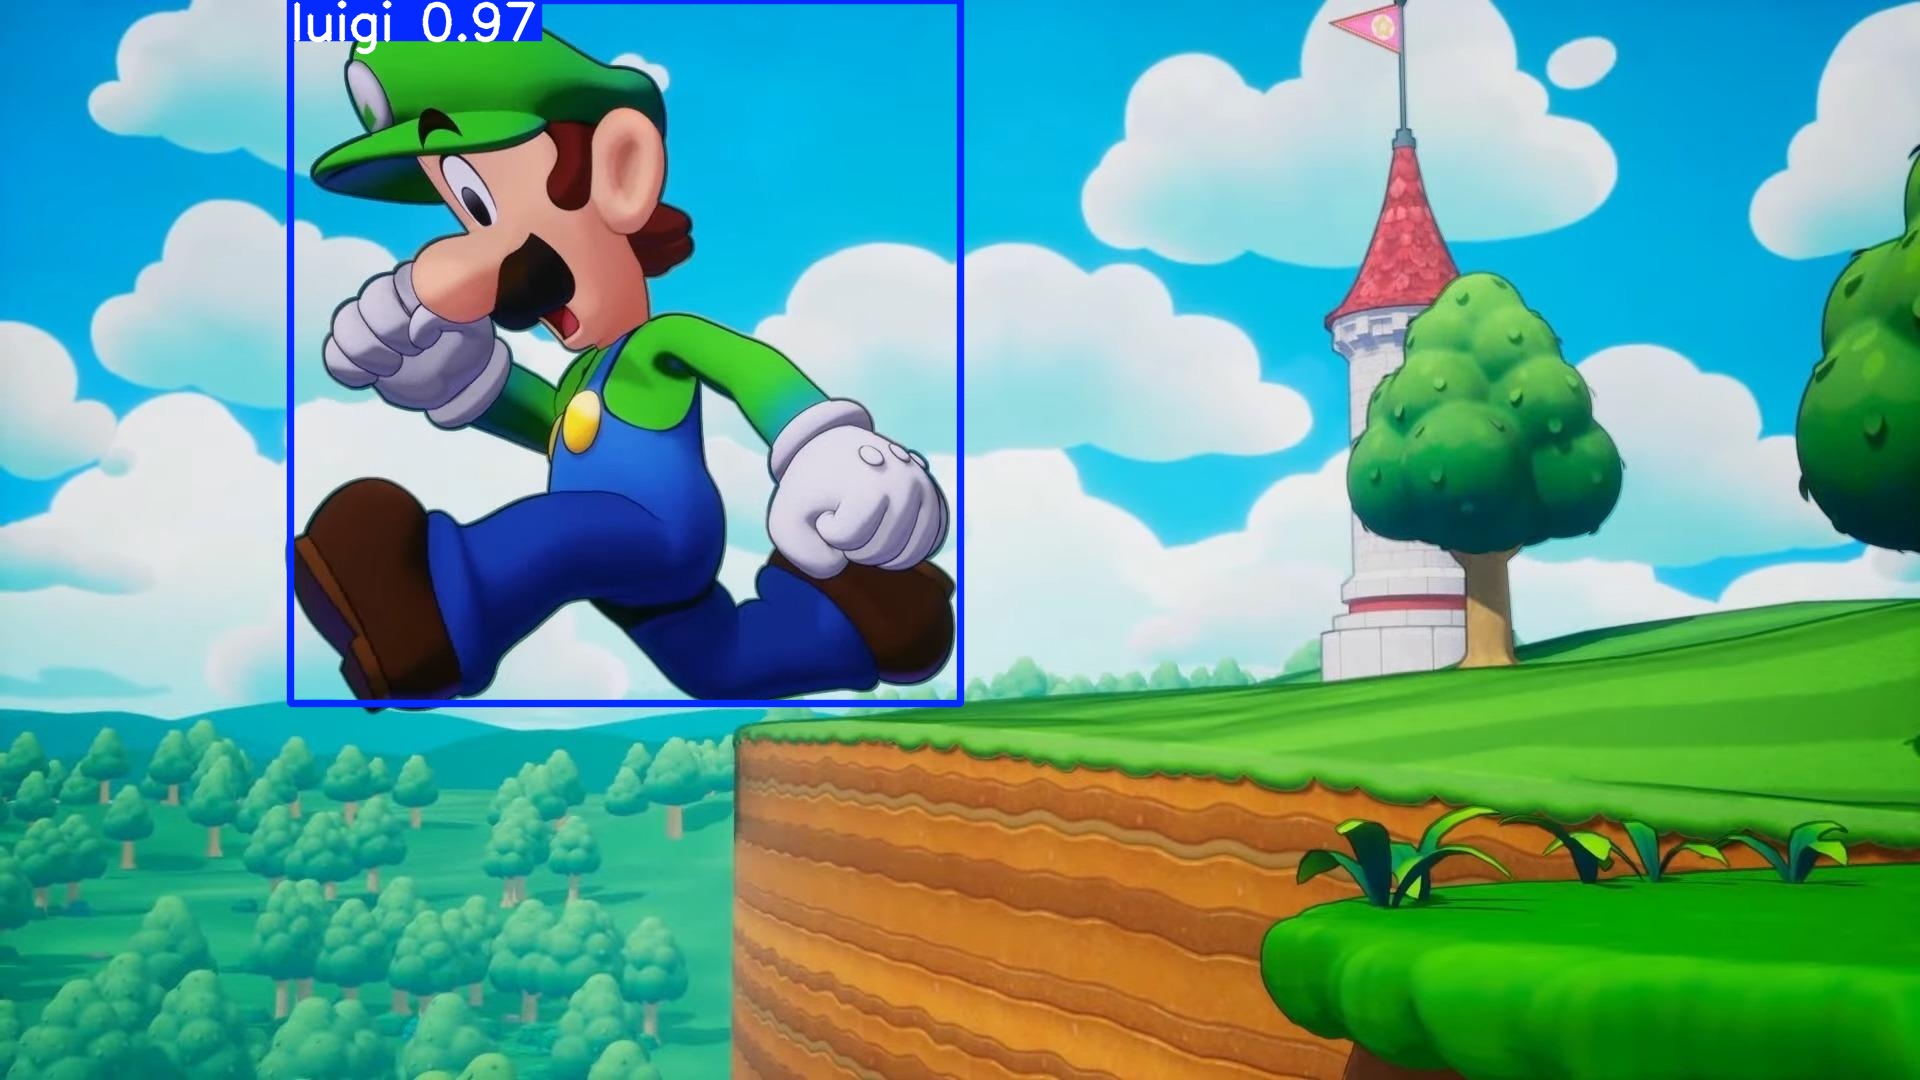

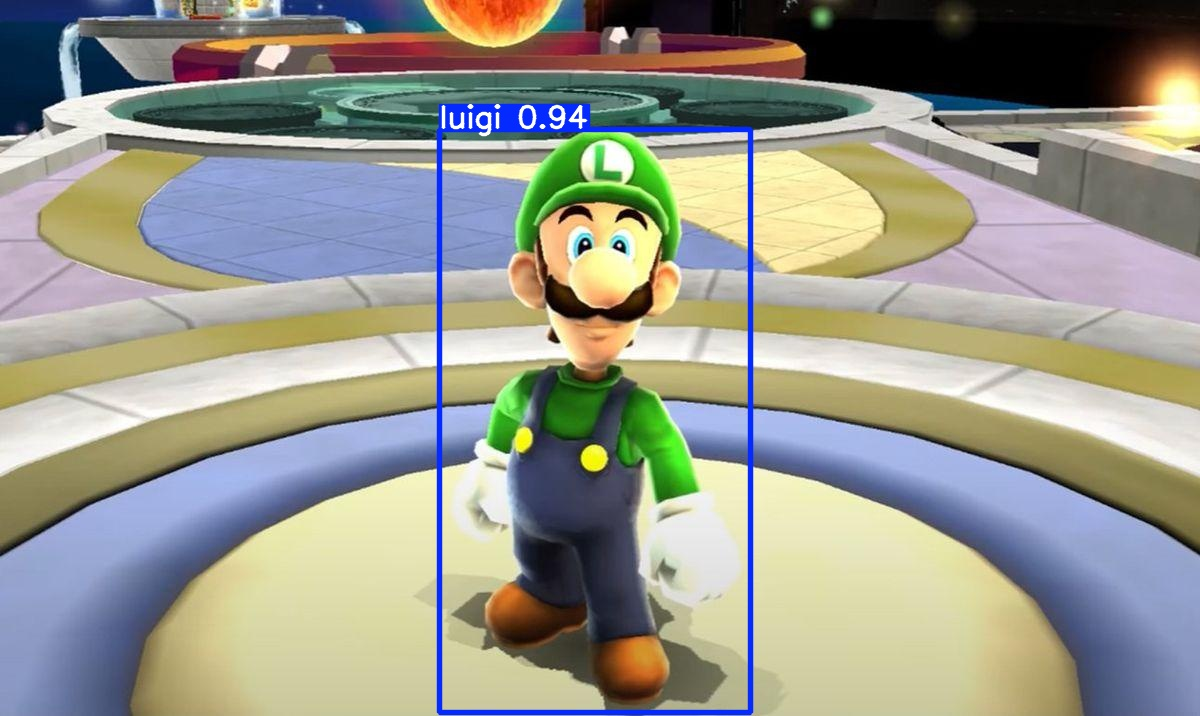

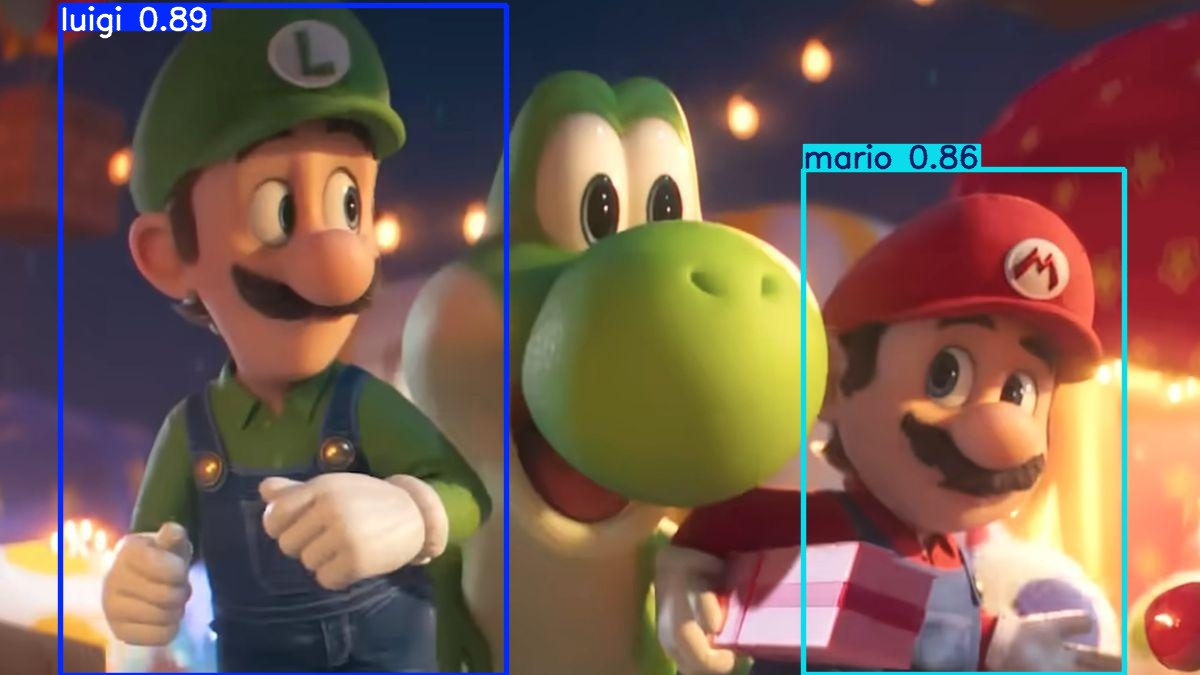

In [ ]:
from IPython.display import Image, display
pred_folder = "runs/detect/predict"
samples = random.sample(os.listdir(pred_folder), 3)

for img in samples:
    display(Image(filename=f"{pred_folder}/{img}"))

## Error Analysis and Reflection

Yolov8n is small/fast but achieved strong overall performance on our small dataset. However some sources of errors were observed.

1. Precision needs improvement

This might be because of similar color patterns between characters and background elements. This might also be due to the limited dataset size.

2. Bounding Boxes Errors (mAP@50-95)

While mAP@50 is high (0.93) mAP@50-95 was lower (0.70). This shows that the bounding boxes are sometimes not correctly located on objects. This issue was more for the Luigi class.

3. Class Errors

Luigi had lower recall and lower mAP@50-95 while Mario achieved perfect recall and higher bounding box accuracy. This is likely because of Mario has more consistent visual features and better representation in the dataset.


Reflection
---

This challenge showed the importance of data quality, and augmentation in object detection.

Overall, the model performs well given the limited dataset and showed effective learing. With additional data and further tuning of augmentation, performance could be improved. The main limitation here is bounding box precision rather than object recognition. The results are realistic when training on small datasets.